### GAN'S-Generative Adversial Networks

### Vanilla GAN

In [1]:
# !pip install torchvision

In [2]:
import torch
import os
from torch.utils.data import DataLoader , Dataset
from torchvision import transforms
from PIL import Image

In [3]:
# Image load => transform => dataset of all images
class ImageProcessor:
    def __init__(self,root_dir_path,transformations=None):
        self.root_dir_path=root_dir_path
        self.transformations=transformations

        # list of path for all images
        self.all_img_paths=[os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self,idx):
        img_path=self.all_img_paths[idx]
        img=Image.open(img_path).convert("RGB")

        if self.transformations:
            img=self.transformations(img)

        return img

In [4]:
root_dir_path="./img_align_celeba"

transformations=transforms.Compose(
    [
        transforms.CenterCrop(178), # 178x218 => 178x178
        transforms.Resize(64), # 64x64
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # [-1,1]
    ]
)

In [5]:
dataset=ImageProcessor(root_dir_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 202597 images


In [6]:
dataloader=DataLoader(dataset,batch_size=128,shuffle=True)

### Generator Network

In [7]:
import torch.nn as nn 
import torch.optim as optim
import numpy as np

In [8]:
class Generator(nn.Module):
    def __init__(self,img_channels=3,z_dim=100):
        super(Generator,self).__init__()

        # fully connected(dense) Layers

        self.model=nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64*64*img_channels),
            nn.Tanh() # [-1,1]
        )

    def forward(self,z):
        img=self.model(z)
        img=img.view(img.size(0),3,64,64)
        return img

    # Fake image => 64 x 64 x 3 x batch_size

### Discriminator Network

In [9]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator,self).__init__()

        self.model=nn.Sequential(
            nn.Flatten(), # 4D Tensor => 1D

            nn.Linear(img_channels*64*64,1024),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid() # 0 or 1 => Probability of being fake or real
        )

    def forward(self,img):
        return self.model(img)

In [10]:
GAN_loss=nn.BCELoss()

In [11]:
generator=Generator()
g_optimizer=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [12]:
discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [13]:
# Device

if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

print(f"Device is {device}")

Device is cuda


In [14]:
generator=generator.to(device)
discriminator=discriminator.to(device)

### Training the GAN's

In [15]:
def train(generator,discriminator,dataloader,epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):

            real_imgs=imgs.to(device)
            batch_size=real_imgs.size(0)

            # Create Real image labels and Fake Image labels
            real_labels=torch.ones(batch_size,1).to(device) # 1,1,1
            fake_labels=torch.zeros(batch_size,1).to(device) # 0,0,0

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs=generator(torch.randn(batch_size,100).to(device))

            real_loss=GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss=GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss=(real_loss+fake_loss)/2

            d_loss.backward()
            d_optimizer.step()

            #Train the Generator
            g_optimizer.zero_grad()

            g_loss=GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch :{epoch+1}/{epochs} , batch :{i+1}, g-loss : {g_loss} and d_loss : {d_loss}")

        # save generated images for each epoch
        save_generated_images(generator,epoch,device)

In [16]:
import matplotlib.pyplot as plt 
import torchvision

def save_generated_images(generator,epoch,device,num_imgs=8):
    z=torch.randn(num_imgs,100).to(device)
    generated_imgs=generator(z).detach().cpu()

    grid=torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    plt.imshow(np.transpose(grid,(1,2,0)))

    plt.title(f"epoch:{epoch+1}")
    plt.axis("off")
    plt.show()

In [17]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [18]:
print(next(generator.parameters()).device)
print(next(discriminator.parameters()).device)

cuda:0
cuda:0


for epoch :1/5 , batch :1, g-loss : 0.7113433480262756 and d_loss : 0.694887638092041
for epoch :1/5 , batch :51, g-loss : 1.041224718093872 and d_loss : 0.25643202662467957
for epoch :1/5 , batch :101, g-loss : 2.215625286102295 and d_loss : 0.1138644814491272
for epoch :1/5 , batch :151, g-loss : 1.084100365638733 and d_loss : 0.26574674248695374
for epoch :1/5 , batch :201, g-loss : 0.8270246982574463 and d_loss : 0.30793267488479614
for epoch :1/5 , batch :251, g-loss : 1.3173155784606934 and d_loss : 0.34908080101013184
for epoch :1/5 , batch :301, g-loss : 1.6313940286636353 and d_loss : 0.14787927269935608
for epoch :1/5 , batch :351, g-loss : 1.670309066772461 and d_loss : 0.1425476223230362
for epoch :1/5 , batch :401, g-loss : 1.20345938205719 and d_loss : 0.21084856986999512
for epoch :1/5 , batch :451, g-loss : 0.49836766719818115 and d_loss : 0.5532070994377136
for epoch :1/5 , batch :501, g-loss : 1.9814079999923706 and d_loss : 0.4093172550201416
for epoch :1/5 , batch :

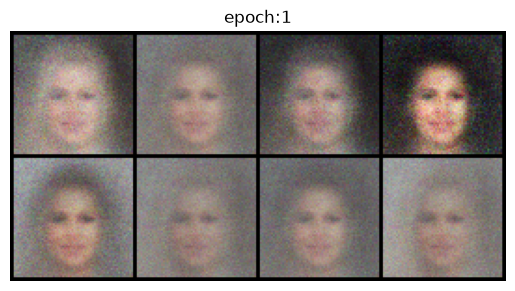

for epoch :2/5 , batch :1, g-loss : 2.999835968017578 and d_loss : 0.6093772053718567
for epoch :2/5 , batch :51, g-loss : 2.554419994354248 and d_loss : 0.24664530158042908
for epoch :2/5 , batch :101, g-loss : 2.853559732437134 and d_loss : 0.19848264753818512
for epoch :2/5 , batch :151, g-loss : 2.439608573913574 and d_loss : 0.22474977374076843
for epoch :2/5 , batch :201, g-loss : 2.653209924697876 and d_loss : 0.27690041065216064
for epoch :2/5 , batch :251, g-loss : 2.6453630924224854 and d_loss : 0.18139570951461792
for epoch :2/5 , batch :301, g-loss : 1.9589641094207764 and d_loss : 0.26465168595314026
for epoch :2/5 , batch :351, g-loss : 2.911011219024658 and d_loss : 0.17046640813350677
for epoch :2/5 , batch :401, g-loss : 2.3237624168395996 and d_loss : 0.47722554206848145
for epoch :2/5 , batch :451, g-loss : 2.57584285736084 and d_loss : 0.24183587729930878
for epoch :2/5 , batch :501, g-loss : 2.4772043228149414 and d_loss : 0.25270938873291016
for epoch :2/5 , batch

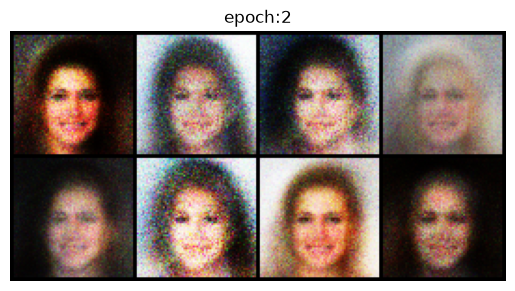

for epoch :3/5 , batch :1, g-loss : 3.0701000690460205 and d_loss : 0.35613495111465454
for epoch :3/5 , batch :51, g-loss : 1.7091937065124512 and d_loss : 0.4848141074180603
for epoch :3/5 , batch :101, g-loss : 2.2461061477661133 and d_loss : 0.3773728311061859
for epoch :3/5 , batch :151, g-loss : 2.7471957206726074 and d_loss : 0.2989789843559265
for epoch :3/5 , batch :201, g-loss : 2.023376941680908 and d_loss : 0.33733105659484863
for epoch :3/5 , batch :251, g-loss : 2.3659098148345947 and d_loss : 0.42076024413108826
for epoch :3/5 , batch :301, g-loss : 2.074765920639038 and d_loss : 0.3282723128795624
for epoch :3/5 , batch :351, g-loss : 2.831963062286377 and d_loss : 0.40045759081840515
for epoch :3/5 , batch :401, g-loss : 1.9847865104675293 and d_loss : 0.4362565279006958
for epoch :3/5 , batch :451, g-loss : 2.0401241779327393 and d_loss : 0.41965559124946594
for epoch :3/5 , batch :501, g-loss : 3.119040012359619 and d_loss : 0.4608404338359833
for epoch :3/5 , batch 

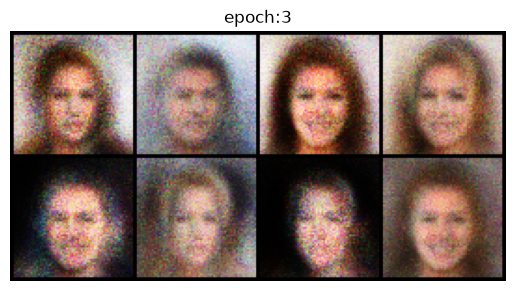

for epoch :4/5 , batch :1, g-loss : 2.7059600353240967 and d_loss : 0.31438297033309937
for epoch :4/5 , batch :51, g-loss : 2.113542079925537 and d_loss : 0.40859711170196533
for epoch :4/5 , batch :101, g-loss : 2.4120030403137207 and d_loss : 0.4662308096885681
for epoch :4/5 , batch :151, g-loss : 2.3045809268951416 and d_loss : 0.49047744274139404
for epoch :4/5 , batch :201, g-loss : 2.3422722816467285 and d_loss : 0.35752296447753906
for epoch :4/5 , batch :251, g-loss : 2.1075870990753174 and d_loss : 0.4576658010482788
for epoch :4/5 , batch :301, g-loss : 1.7634203433990479 and d_loss : 0.4073963165283203
for epoch :4/5 , batch :351, g-loss : 2.7608284950256348 and d_loss : 0.2971489429473877
for epoch :4/5 , batch :401, g-loss : 2.6748218536376953 and d_loss : 0.42241084575653076
for epoch :4/5 , batch :451, g-loss : 2.244366407394409 and d_loss : 0.37105515599250793
for epoch :4/5 , batch :501, g-loss : 1.719956636428833 and d_loss : 0.48426634073257446
for epoch :4/5 , bat

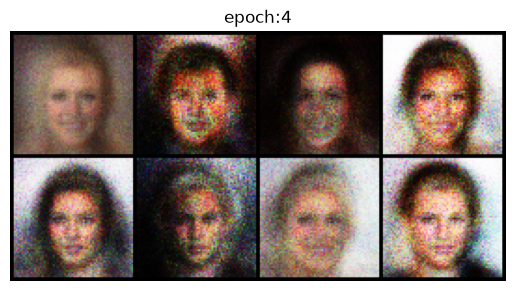

for epoch :5/5 , batch :1, g-loss : 2.2653770446777344 and d_loss : 0.3879568576812744
for epoch :5/5 , batch :51, g-loss : 2.041914939880371 and d_loss : 0.39029741287231445
for epoch :5/5 , batch :101, g-loss : 2.1183931827545166 and d_loss : 0.4714249074459076
for epoch :5/5 , batch :151, g-loss : 1.5648901462554932 and d_loss : 0.5088074803352356
for epoch :5/5 , batch :201, g-loss : 2.7526957988739014 and d_loss : 0.563820481300354
for epoch :5/5 , batch :251, g-loss : 2.325399398803711 and d_loss : 0.47312623262405396
for epoch :5/5 , batch :301, g-loss : 1.9792665243148804 and d_loss : 0.4309726357460022
for epoch :5/5 , batch :351, g-loss : 1.8370444774627686 and d_loss : 0.4869450628757477
for epoch :5/5 , batch :401, g-loss : 1.6528130769729614 and d_loss : 0.44424280524253845
for epoch :5/5 , batch :451, g-loss : 1.7328829765319824 and d_loss : 0.4836973249912262
for epoch :5/5 , batch :501, g-loss : 1.760115623474121 and d_loss : 0.4086986184120178
for epoch :5/5 , batch :5

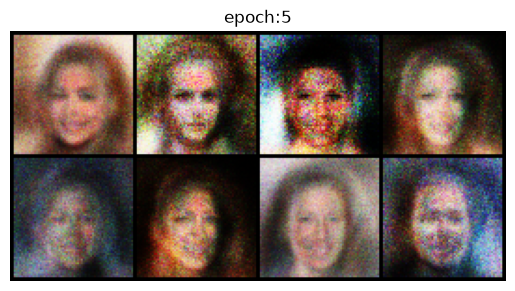

In [19]:
train(generator,discriminator,dataloader,epochs=5)